# Fitting Delta Function with Burst Model

In [1]:
import os
import math
import numpy as np
import bagpipes as pipes
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl

Bagpipes: Latex turned off in rcParams, plots may look strange.
Bagpipes: PyMultiNest import failed, fitting will use the Nautilus sampler instead.


In [2]:
z = 2

import os
import math
import numpy as np
import bagpipes as pipes
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib as mpl

In [3]:
filter_folder = r"D:\Users\nina\Star_Formation_Histories\Filters"

filter_files = sorted([
    os.path.join(filter_folder, f)
    for f in os.listdir(filter_folder)
    if f.endswith(".txt")
])

global_min = np.inf
global_max = -np.inf

for ffile in filter_files:
    data = np.loadtxt(ffile)
    global_min = min(global_min, data[:,0].min())
    global_max = max(global_max, data[:,0].max())

print(f"Wavelength coverage: {global_min:.0f}–{global_max:.0f} Å")

Wavelength coverage: 3526–50996 Å


In [4]:
ages_myr_1 = np.arange(0,110,10)
ages_myr_2 = np.arange(200,1100,100)
years = np.concatenate([ages_myr_1, ages_myr_2]) / 1000

dust = {
    "type": "Calzetti",
    "Av": 0.2,
    "eta": 2.
}

nebular = {
    "logU": -3.
}

In [5]:
def burst_model(t, z, dust, nebular):
    return {
        "redshift": z,
        "burst": {"age": t, "massformed": 10, "metallicity": 0.5},
        "dust": dust,
        "nebular": nebular,
        "t_bc": 0.01,
        "veldisp": 200.
    }


def compute_filter_wavelengths(filter_files):
    eff_waves = []
    for ffile in filter_files:
        filt_data = np.loadtxt(ffile)
        wave = filt_data[:, 0]
        transmission = filt_data[:, 1]
        eff_wave = np.sum(wave * transmission) / np.sum(transmission)
        eff_waves.append(eff_wave)
    return np.array(eff_waves)


def build_models(years, z, dust, nebular, filter_files, wavelength_range):

    models = []

    for t in years:
        components = burst_model(t, z, dust, nebular)

        model = pipes.model_galaxy(
            components,
            filt_list=filter_files,
            spec_wavs=wavelength_range
        )

        models.append(model)

    return models

In [6]:
wavelength_range = np.arange(
    global_min - 500,
    global_max + 500,
    5.
)

filter_wavelengths = compute_filter_wavelengths(filter_files)

models = build_models(
    years,
    z,
    dust,
    nebular,
    filter_files,
    wavelength_range
)

In [7]:
SNR = 10

synthetic_flux = np.array([model.photometry for model in models])  # F_lambda

c = 2.99792458e18  # Å/s

flux_nu = synthetic_flux * (filter_wavelengths**2) / c
flux_nu = flux_nu / 1e-23      # Jy
flux_in_microjansky = flux_nu * 1e6

err_in_microjansky = flux_in_microjansky / SNR

In [8]:
galaxy_values = []

for age in years:

    age_idx = np.argmin(np.abs(years - age))

    print(f"Fitting model with age = {years[age_idx]:.3f} Gyr")

    galaxy_photometry = np.c_[
        flux_in_microjansky[age_idx],
        err_in_microjansky[age_idx]
    ]

    galaxy = pipes.galaxy(
        str(years[age_idx]),
        lambda ID: galaxy_photometry,
        spectrum_exists=False,
        filt_list=filter_files
    )

    galaxy_values.append(galaxy)

Fitting model with age = 0.000 Gyr
Fitting model with age = 0.010 Gyr
Fitting model with age = 0.020 Gyr
Fitting model with age = 0.030 Gyr
Fitting model with age = 0.040 Gyr
Fitting model with age = 0.050 Gyr
Fitting model with age = 0.060 Gyr
Fitting model with age = 0.070 Gyr
Fitting model with age = 0.080 Gyr
Fitting model with age = 0.090 Gyr
Fitting model with age = 0.100 Gyr
Fitting model with age = 0.200 Gyr
Fitting model with age = 0.300 Gyr
Fitting model with age = 0.400 Gyr
Fitting model with age = 0.500 Gyr
Fitting model with age = 0.600 Gyr
Fitting model with age = 0.700 Gyr
Fitting model with age = 0.800 Gyr
Fitting model with age = 0.900 Gyr
Fitting model with age = 1.000 Gyr


## Fitting

In [11]:

continuity = {
    "massformed": (5., 12.),
    "metallicity": (0.0001, 2.),
    "metallicity_prior": "log_10",

    "bin_edges": [0., 0.01, 0.03, 0.1, 0.3, 1.0],

    "dsfr1": (-5., 5.),
    "dsfr2": (-5., 5.),
    "dsfr3": (-5., 5.),
    "dsfr4": (-5., 5.)
}
# Dust
dust_fit = {
    "type": "Calzetti",
    "Av": (0., 2.)
}

# Fit instructions
fit_instructions = {
    "redshift": z,
    "continuity": continuity,
    "dust": dust_fit,
    "nebular": {"logU": (-4., -2.)}
}

In [13]:
fits = []

for i, galaxy in enumerate(galaxy_values):

    print(f"Running fit {i+1}/{len(galaxy_values)}  (Age = {years[i]:.3f} Gyr)")

    fit = pipes.fit(galaxy, fit_instructions)
    fit.fit(verbose=True)

    fits.append(fit)

print("All fits finished.")

Running fit 1/20  (Age = 0.000 Gyr)


d:\Users\nina\Star_Formation_Histories\bagpipes_env\Lib\site-packages\bagpipes\models\star_formation_history.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  self.component_sfrs[name] *= desired_mass/mass_norm
d:\Users\nina\Star_Formation_Histories\bagpipes_env\Lib\site-packages\bagpipes\models\star_formation_history.py:105: RuntimeWarning: invalid value encountered in multiply
  self.component_sfrs[name] *= desired_mass/mass_norm



Results loaded from pipes/posterior/./0.0.h5

Fitting not performed as results have already been loaded from pipes/posterior/./0.0.h5. To start over delete this file or change run.

Running fit 2/20  (Age = 0.010 Gyr)

Results loaded from pipes/posterior/./0.01.h5

Fitting not performed as results have already been loaded from pipes/posterior/./0.01.h5. To start over delete this file or change run.

Running fit 3/20  (Age = 0.020 Gyr)
MultiNest not available. Switching to nautilus.

Bagpipes: fitting object 0.02

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 1      | 0        | 0        | 40100    | N/A    | 40100 | -110.70  

Completed in 156.2 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
continuity:dsfr1       

d:\Users\nina\Star_Formation_Histories\bagpipes_env\Lib\site-packages\bagpipes\models\star_formation_history.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  self.component_sfrs[name] *= desired_mass/mass_norm
d:\Users\nina\Star_Formation_Histories\bagpipes_env\Lib\site-packages\bagpipes\models\star_formation_history.py:105: RuntimeWarning: invalid value encountered in multiply
  self.component_sfrs[name] *= desired_mass/mass_norm


Running fit 4/20  (Age = 0.030 Gyr)
MultiNest not available. Switching to nautilus.

Bagpipes: fitting object 0.03

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 1      | 0        | 0        | 40100    | N/A    | 40100 | -104.77  

Completed in 152.3 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
continuity:dsfr1              -3.381      0.034      3.423
continuity:dsfr2              -3.419      0.003      3.419
continuity:dsfr3              -3.399     -0.001      3.410
continuity:dsfr4              -3.407      0.003      3.382
continuity:massformed          6.123      8.521     10.870
continuity:metallicity         0.000      0.014      0.403
dust:Av                        0.328      1.003      1.677
nebular:logU  

...

Running fit 19/20  (Age = 0.900 Gyr)
MultiNest not available. Switching to nautilus.

Bagpipes: fitting object 0.9

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 1      | 0        | 0        | 40000    | N/A    | 40000 | -54.39   

Completed in 157.0 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
continuity:dsfr1              -3.417      0.012      3.404
continuity:dsfr2              -3.388     -0.032      3.374
continuity:dsfr3              -3.415     -0.048      3.384
continuity:dsfr4              -3.411      0.013      3.402
continuity:massformed          6.115      8.487     10.886
continuity:metallicity         0.000      0.013      0.412
dust:Av                        0.320      1.000      1.673
nebular:logU  

d:\Users\nina\Star_Formation_Histories\bagpipes_env\Lib\site-packages\bagpipes\models\star_formation_history.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  self.component_sfrs[name] *= desired_mass/mass_norm
d:\Users\nina\Star_Formation_Histories\bagpipes_env\Lib\site-packages\bagpipes\models\star_formation_history.py:105: RuntimeWarning: invalid value encountered in multiply
  self.component_sfrs[name] *= desired_mass/mass_norm


Running fit 20/20  (Age = 1.000 Gyr)
MultiNest not available. Switching to nautilus.

Bagpipes: fitting object 1.0

Starting the nautilus sampler...
Please report issues at github.com/johannesulf/nautilus.
Status    | Bounds | Ellipses | Networks | Calls    | f_live | N_eff | log Z    
Finished  | 1      | 0        | 0        | 40000    | N/A    | 40000 | -54.39   

Completed in 155.2 seconds.

Parameter                          Posterior percentiles
                                16th       50th       84th
----------------------------------------------------------
continuity:dsfr1              -3.407      0.007      3.406
continuity:dsfr2              -3.363     -0.010      3.385
continuity:dsfr3              -3.380      0.010      3.389
continuity:dsfr4              -3.412     -0.027      3.420
continuity:massformed          6.119      8.502     10.878
continuity:metallicity         0.000      0.014      0.402
dust:Av                        0.325      1.002      1.680
nebular:logU  

d:\Users\nina\Star_Formation_Histories\bagpipes_env\Lib\site-packages\bagpipes\models\star_formation_history.py:105: RuntimeWarning: divide by zero encountered in scalar divide
  self.component_sfrs[name] *= desired_mass/mass_norm
d:\Users\nina\Star_Formation_Histories\bagpipes_env\Lib\site-packages\bagpipes\models\star_formation_history.py:105: RuntimeWarning: invalid value encountered in multiply
  self.component_sfrs[name] *= desired_mass/mass_norm


All fits finished.



Plotting results for age 0.000 Gyr


d:\Users\nina\Star_Formation_Histories\bagpipes_env\Lib\site-packages\bagpipes\models\model_galaxy.py:588: RuntimeWarning: divide by zero encountered in log10
  self.uvj = -2.5*np.log10(self._calculate_photometry(0., uvj=True))


ValueError: zero-size array to reduction operation minimum which has no identity

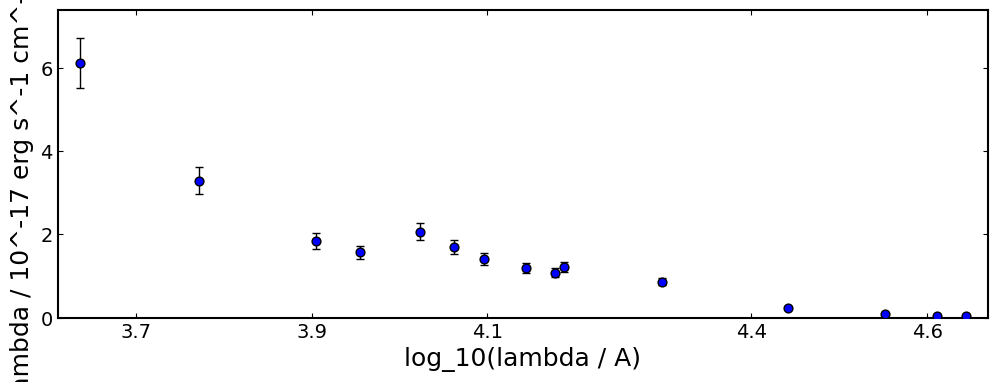

In [14]:
for i, fit in enumerate(fits):

    print(f"\nPlotting results for age {years[i]:.3f} Gyr")

    fit.plot_spectrum_posterior(show=True, save=False)

    fit.plot_sfh_posterior(show=True, save=False)

    fit.plot_corner(show=True, save=False)